This experiment verifies the distribution of message recipients for dragonfly topology 

# 0. User Parameters, Imports, Environment

## User Parameters

In [14]:
import os

# Path to the directory containing the merlin benchmark workflow and examples
workflow_dir = '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/'


# Path to the directory where the output of the experiment runs will be stored
experiment_name = 'dragonfly_verification'

# Configuration parameters
node_counts = [1,2]
groups_per_node = 1 # Total groups will scale with the number of nodes
routers_per_group = 8 
hosts_per_router = 8

# Whether to force re-running experiments even if they have already been completed
# If set to 0, existing results will be used instead of rerunning experiments
FORCED = 1

# Path to the directory containing the apptainer executable
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'

# Path where apptainer should store its cache
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'

# URL of the SST container to be used for the workflow and the destination path where it should be saved.
# If the destination path is already created, the container will not be downloaded and the url will be ignored.
sst_container_url = 'ghcr.io/hpc-ai-adv-dev/sst-perf-track-full:16.0.0'
sst_container_dest_name = 'sst-perf-track-full.sif'


print(f'workflow_dir: {workflow_dir}')

workflow_dir: /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


## Calculated 'Constants'

In [15]:
# Full path to the SST input configuration file
sst_input_config = os.path.join(workflow_dir, 'merlin_benchmark.py')

# Directory containing per-simulation subdirectories
output_dir = os.path.join(workflow_dir, experiment_name + '_out')

# Full path to where the final .sif containerfile will live
sst_container_dest_path = os.path.join(workflow_dir, sst_container_dest_name)

# CSV file containing the consolidated experiment results after all simulations
# have been completed
experiment_result_file = os.path.join(workflow_dir, f'{experiment_name}_results.csv')

sst_input_config
sst_container_dest_path

'/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif'

## Imports

In [16]:
from workflow_utils import *
import os
import sys
sys.path.append(workflow_dir)
import workflow_args
import json
import glob
import humanfriendly
import pandas as pd
from plotnine import *

## Environment + Checks

In [17]:
os.environ["PATH"] += os.pathsep + apptainer_bin_path
#os.environ["PATH"] += os.pathsep + e4s_cl_path
os.environ["LANG"] = "C.UTF-8"
os.environ["LC_ALL"] = "C.UTF-8"
os.environ['APPTAINER_CACHEDIR'] = apptainer_cache_dir

# 1. Download and Prepare Containers

## Download containers, create `.sif`

In [18]:
cd(workflow_dir)

get_convert_to_sif()

# script expects there not to be an extension on the output file name
if os.path.exists(sst_container_dest_path):
    print(f"{sst_container_dest_path} already exists.")
else:
    run_cmd(f"./convert-to-sif.sh {sst_container_url} -o {workflow_dir} -f {sst_container_dest_name.replace('.sif', '')}")



> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif already exists.


## Prepare the e4s-cl profile

In [19]:
run_cmd(f"e4s-cl profile edit --add-files {workflow_dir}")
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.py')
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.so')
run_cmd(f'e4s-cl profile edit --image {sst_container_dest_path}')

> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.py


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.py already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.so


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.so already in profile's files


> e4s-cl profile edit --image /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif


## Check that the profile injects a host MPI

If the selected e4s-cl profile has no MPI library bound, e4s-cl performs no MPI
substitution. The container's own MPI then finds no process manager and falls
back to *singleton init*, so every task silently becomes rank 0 of a 1-rank job
instead of one N-rank simulation.


In [20]:
check_mpi_binding(sst_container_dest_path)

e4s-cl profile : sst-experiments
profile image  : /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif
container SST  : /opt/SST/16.0.0/libexec/sstsim.x
container MPI  : libmpi.so.12
bound host MPI : libmpi_cray.so.12 -> /opt/cray/pe/lib64/libmpi_cray.so.12
bound host PMI : libpals.so.0, libpmi.so.0, libpmi2.so.0
OK: e4s-cl will inject a host MPI into the container.


True

# 2. Build Benchmarks

In [ ]:
# Run Make within the container
# We have to create and mount this .conf file for SST to use when running
run_cmd('touch sstsimulator.conf')
run_in_container('make clean', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')
run_in_container('make -j10', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')

> touch sstsimulator.conf
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark:/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--pwd', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--bind', 'sstsimulator.conf:/home/users/neth/.sst/sstsimulator.conf', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif', 'bash', '-lc', 'make -j10']
g++ -std=c++17  -std=c++17 -fexcess-precision=fast -fPIC -DHAVE_CONFIG_H -I/opt/SST/16.0.0/include -g -shared -fno-common -Wl,-undefined -Wl,dynamic_lookup "-DENABLE_SSTCHECKPOINT" -o libmerlin_benchmark.so src/trafficgen.cc


src/trafficgen.cc: In member function ‘bool SST::MerlinBenchmark::TrafficGen::clock_handler(SST::Cycle_t)’:
src/trafficgen.cc:283:68: warning: format ‘%lld’ expects argument of type ‘long long int’, but argument 9 has type ‘SST::Interfaces::SimpleNetwork::nid_t’ {aka ‘long int’} [-Wformat=]
  283 |         out.verbose(CALL_INFO, 5, 0, "Node %d sending packet to %lld of size %zu bits.\n", id, req->dest, req->size_in_bits);
      |                                                                 ~~~^                           ~~~~~~~~~
      |                                                                    |                                |
      |                                                                    long long int                    SST::Interfaces::SimpleNetwork::nid_t {aka long int}
      |                                                                 %ld
src/trafficgen.cc: In member function ‘bool SST::MerlinBenchmark::TrafficGen::handle_receives(int)’:
src/trafficge

/opt/SST/16.0.0/bin//sst-register merlin_benchmark merlin_benchmark_LIBDIR=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark


# 3. Generate Argument Tuples

In [22]:
run_specs = []
for node_count in node_counts:
    num_groups = groups_per_node * node_count
    run_specs += workflow_args.generate_merlin_run_specs(
        node_counts = (node_count,),
        topologies=('dragonfly',),
        global_params={'stop_at': (100),
                       'verbose': 5},
        dragonfly_params={
            'dragonfly_hosts_per_router': (hosts_per_router,),
            'dragonfly_num_groups': (num_groups,),
            'dragonfly_routers_per_group' : (routers_per_group,)
        },
        experiment_name=experiment_name)
print(f"Generated {len(run_specs)} run specifications.")
print(f'Example spec: ', run_specs[0])

Generated 2 run specifications.
Example spec:  MerlinRunSpec(run_id='70f9ca9ee0', run_name='dragonfly_verification_dragonfly_n1_r1_70f9ca9ee0', launcher={'srun': ['--nodes=1', '--ntasks-per-node=1'], 'mpirun': ['-n', '1', '-N', '1']}, sst_args=['--timing-info=3', '--parallel-load=SINGLE'], config_args=['--dragonfly-adaptive-threshold', '2.0', '--dragonfly-algorithm', 'minimal', '--dragonfly-global-routing-mode', 'absolute', '--dragonfly-hosts-per-router', '8', '--dragonfly-intergroup-links', '1', '--dragonfly-num-groups', '1', '--dragonfly-routers-per-group', '8', '--flit-size-bytes', '8', '--link-bw-gbps', '4', '--link-lat-ns', '1', '--stop-at', '100ns', '--tg-input-buf-size', '4kB', '--tg-input-latency', '20ns', '--tg-output-buf-size', '4kB', '--tg-output-latency', '20ns', '--topology', 'dragonfly', '--verbose', '5', '--xbar-bw-gbps', '4'], metadata={'experiment_name': 'dragonfly_verification', 'run_name': 'dragonfly_verification_dragonfly_n1_r1_70f9ca9ee0', 'run_id': '70f9ca9ee0', '

# 4. Launch Runs

In [23]:

os.makedirs(output_dir, exist_ok=True)

for run_spec in run_specs:
    run_output_dir = os.path.join(output_dir, run_spec.run_name)
    os.makedirs(run_output_dir, exist_ok=True)
    cd(run_output_dir)

    status_file_path = os.path.join(run_output_dir, 'status.txt')

    if os.path.exists(status_file_path):
        with open(status_file_path, 'r') as f:
            status = f.read().strip()
        if not FORCED and status in ['COMPLETED', 'SUBMITTED']:
            print(f'Skipping {run_spec.run_name} as it is already {status}')
            continue

    log_file = os.path.join(run_output_dir, 'run.log')
    error_file = os.path.join(run_output_dir, 'run.err')
    profiling_output_file = os.path.join(run_output_dir, 'profiling.json')

    param_file = os.path.join(run_output_dir, 'params.json')
    with open(param_file, 'w') as f:
        json.dump(run_spec.to_dict(), f, indent=2)


    srun_part = " ".join(run_spec.launcher["srun"])
    sst_part = " ".join(run_spec.sst_args)
    config_part = " ".join(run_spec.config_args)

    launch_cmd = (
        f"e4s-cl launch srun --output={log_file} --error={error_file} "
        f"{srun_part} \\\n\t -- sst --profiling-output={profiling_output_file} --timing-info=3 {sst_input_config} "
        f"{sst_part} \\\n\t -- {config_part}"
    )

    
    sbatch_script_path = os.path.join(run_output_dir, 'run.sbatch')

    with open(sbatch_script_path, 'w') as f:
        f.write(f"#!/bin/bash\n")
        f.write(f"echo 'LAUNCHED' > {status_file_path}\n")
        f.write(f"{launch_cmd}\n")
        f.write(f"if [ $? -eq 0 ]; then\n")
        f.write(f"    echo 'COMPLETED' > {status_file_path}\n")
        f.write(f"else\n")
        f.write(f"    echo 'FAILED' > {status_file_path}\n")
        f.write(f"fi\n")

    os.chmod(sbatch_script_path, 0o755)

    sbatch_log = os.path.join(run_output_dir, 'sbatch.log')
    sbatch_err = os.path.join(run_output_dir, 'sbatch.err')
    sbatch_cmd = f"sbatch --job-name={experiment_name} --output={sbatch_log} --error={sbatch_err} {srun_part} {sbatch_script_path}"
    sbatch_submit_file = os.path.join(run_output_dir, 'sbatch_submit_cmd.txt')
    with open(sbatch_submit_file, 'w') as f:
        f.write(f"{sbatch_cmd}\n")

    with open(status_file_path, 'w') as f:
        f.write('SUBMITTED\n')
    run_cmd(sbatch_cmd)

    cd(workflow_dir)

> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verification_dragonfly_n1_r1_70f9ca9ee0
> sbatch --job-name=dragonfly_verification --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verification_dragonfly_n1_r1_70f9ca9ee0/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verification_dragonfly_n1_r1_70f9ca9ee0/sbatch.err --nodes=1 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verification_dragonfly_n1_r1_70f9ca9ee0/run.sbatch
Submitted batch job 1639072
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verification_dragonfly_n2_r1_caae09edc9
> sbatch --job-name=dragonfly_verification --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verificat

# 5. Wait for Job Completion

In [24]:
wait_for_jobs(job_name=experiment_name)

Waiting for jobs to complete... Queue length: 2


Waiting for jobs to complete... Queue length: 2


# 6. Collect Simulation Results

In [30]:
log_files = glob.glob(f'{output_dir}/**/run.log', recursive=True)
    
print(log_files)
columns = []
for log_file in log_files:
    msgs = []
    with open(log_file, 'r') as f:
        for line in f:
            if line.startswith('CHECK'):
                #CHECK 1000: Node 154 sending packet to 519 of size 64 bits.
                tokens = line.split()
                # Example tokens: ['CHECK', '1000:', 'Node', '154', 'sending', 'packet', 'to', '519', 'of', 'size', '64', 'bits.']
                if len(tokens) < 11:
                    continue
                msgs.append({
                    'file' : log_file,
                    'timestamp': tokens[1].rstrip(':'),
                    'src_node': tokens[3],
                    'dst_node': tokens[7],
                    'type': tokens[4]
                })
    columns.extend(msgs)

df = pd.DataFrame(columns)

df.to_csv(experiment_result_file, index=False)


['/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verification_dragonfly_n1_r1_70f9ca9ee0/run.log', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_verification_out/dragonfly_verification_dragonfly_n2_r1_caae09edc9/run.log']


# 7. Analyze Results

In [31]:
df = pd.read_csv(experiment_result_file)
df['file'] = df['file'].str.split('/').str[-2].str.split('_').str[-3]
df.head()

,file,timestamp,src_node,dst_node,type
0,n1,1000,0,35,sending
1,n1,1000,1,26,sending
2,n1,1000,2,27,sending
3,n1,1000,3,35,sending
4,n1,1000,4,61,sending


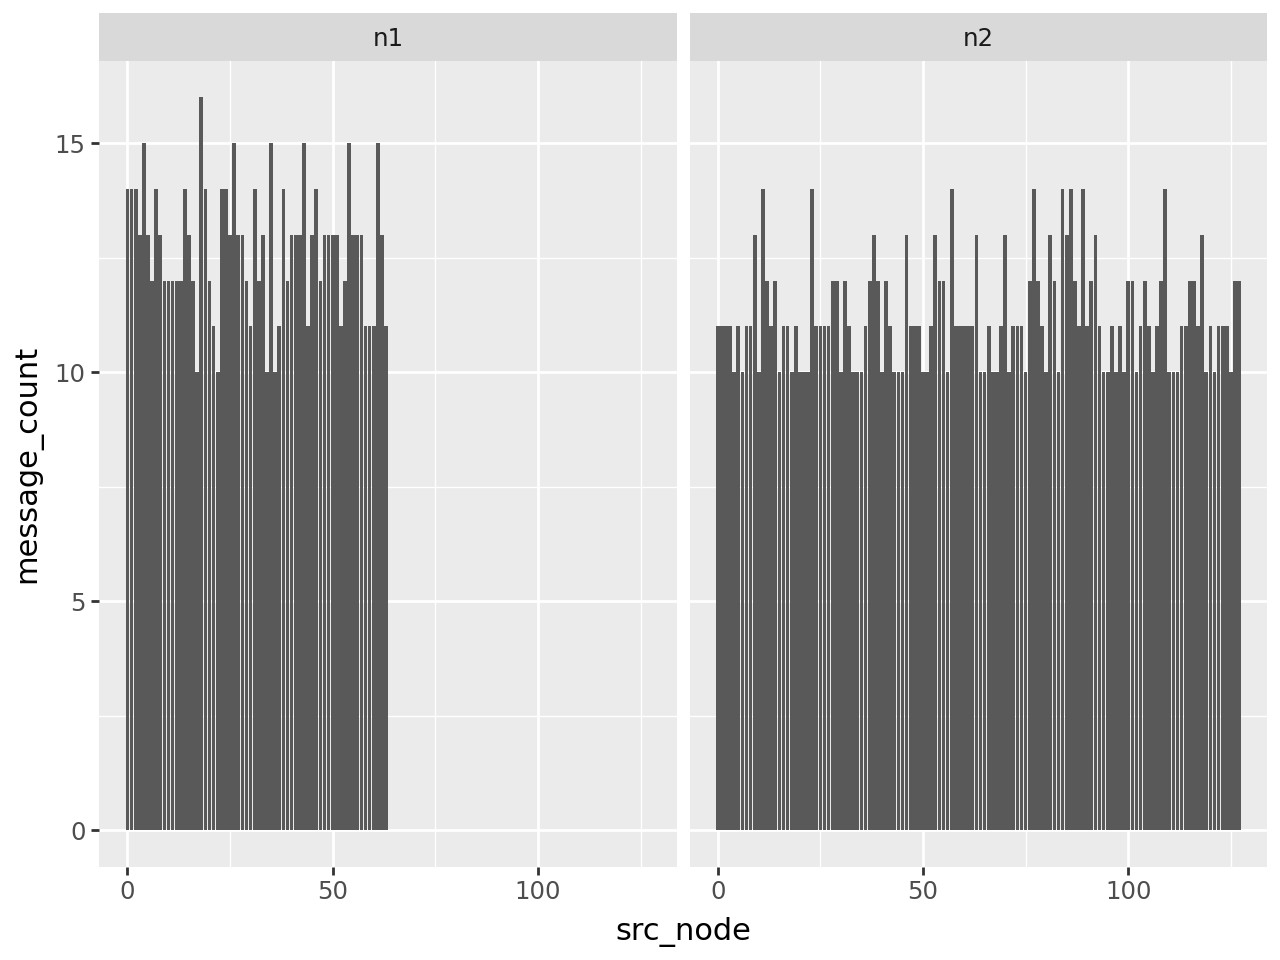

In [32]:
gb = df[df['type'] == 'sending'].groupby(['file', 'src_node']).size()
counts_df = gb.reset_index(name='message_count')
counts_df
p = ggplot(counts_df)
p += geom_bar(aes(x='src_node', y='message_count'), stat='identity')
p += facet_wrap('~file')
p

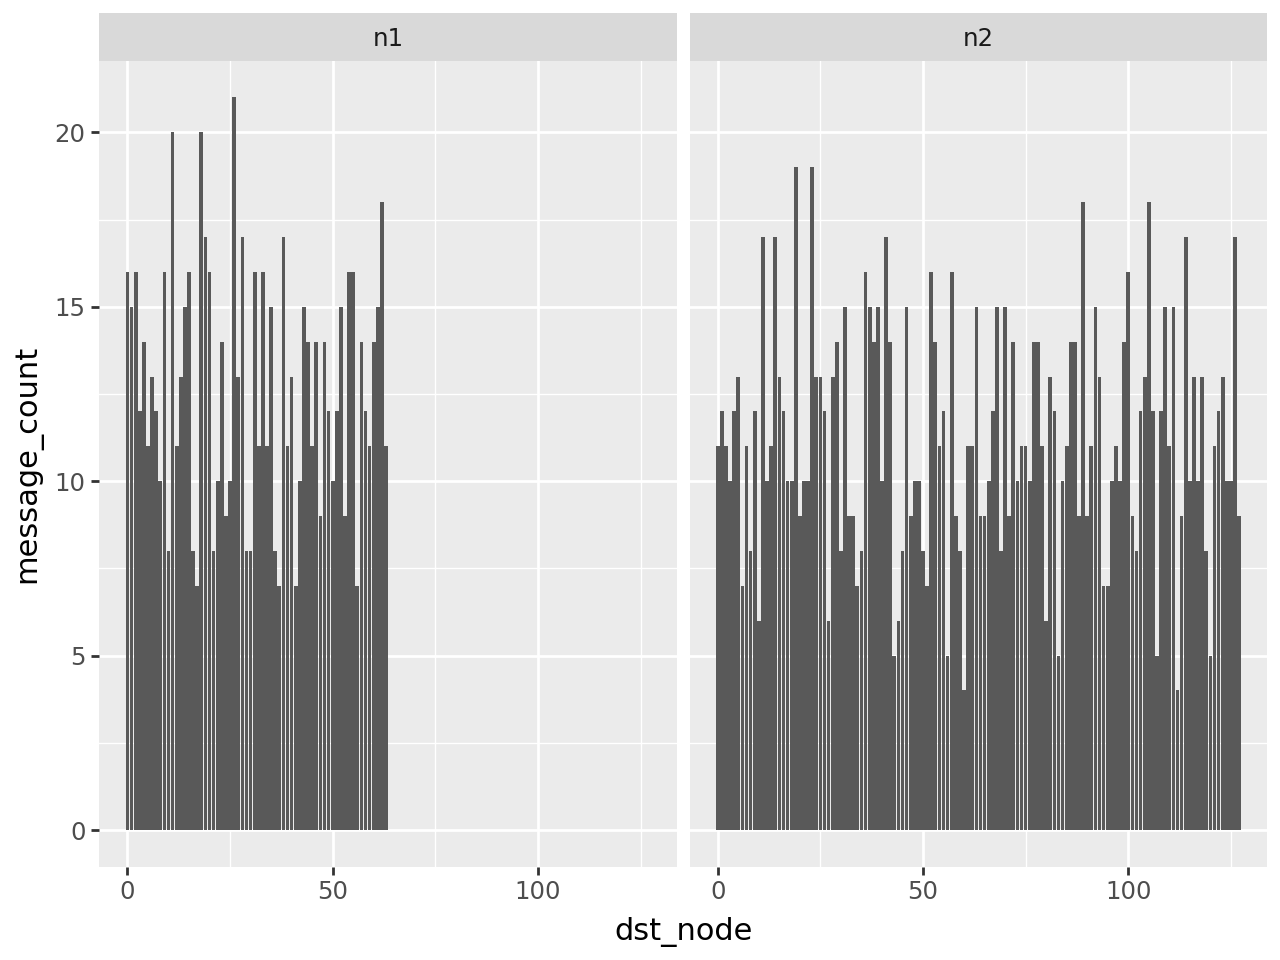

In [28]:
gb = df[df['type'] == 'sending'].groupby(['file', 'dst_node']).size()
counts_df = gb.reset_index(name='message_count')
counts_df
p = ggplot(counts_df)
p += geom_bar(aes(x='dst_node', y='message_count'), stat='identity')
p += facet_wrap('~file')
p

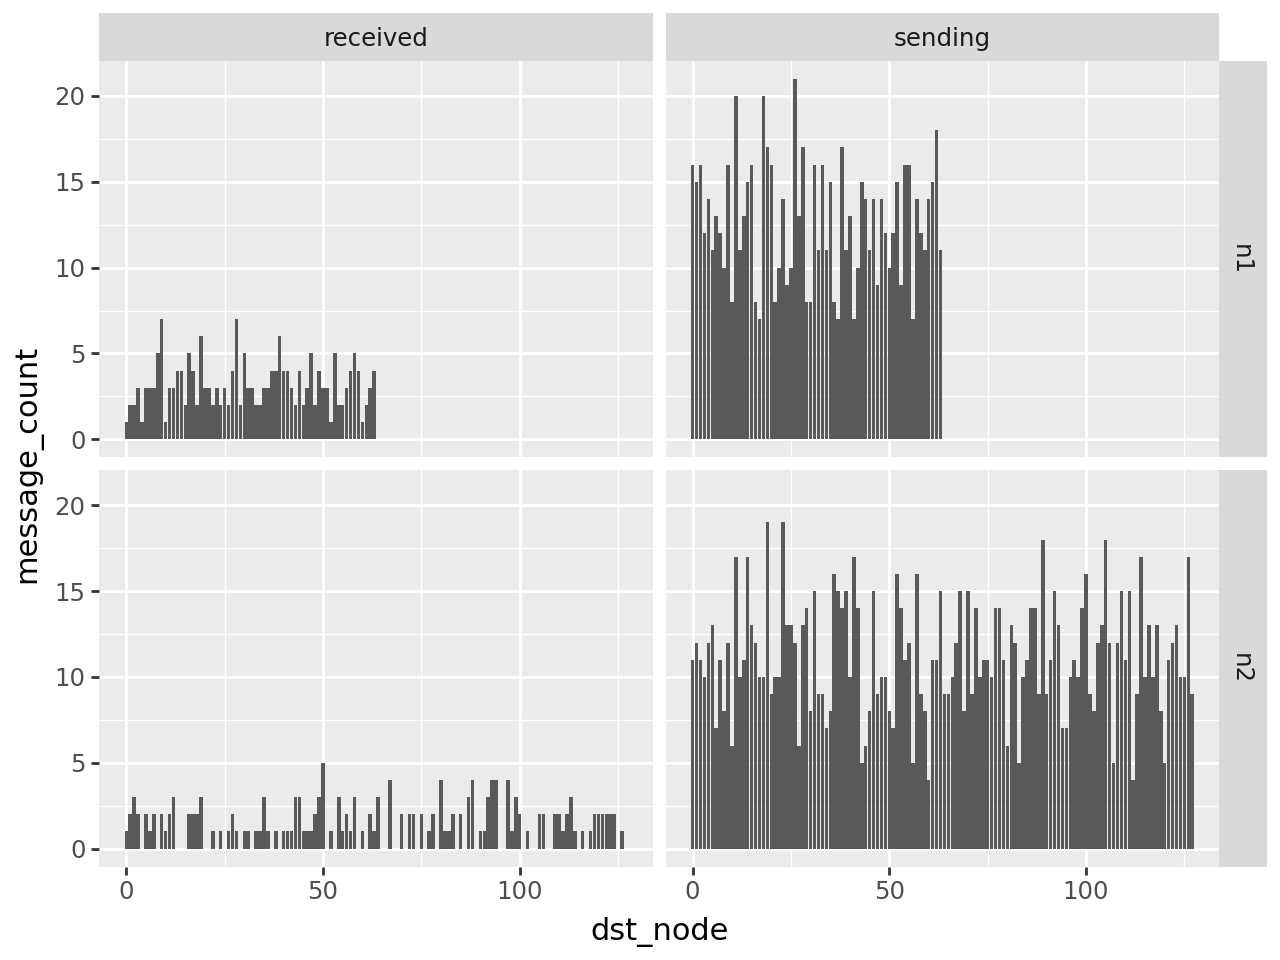

In [29]:
gb = df.groupby(['type', 'file', 'dst_node']).size()
counts_df = gb.reset_index(name='message_count')
counts_df
p = ggplot(counts_df)
p += geom_bar(aes(x='dst_node', y='message_count'), stat='identity')
p += facet_grid('file~type')
p

In [ ]:
gb = df.groupby(['timestamp', 'type', 'file', 'src_node']).size()